In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df = df.iloc[:,1:]

In [4]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df = df[df['Species'] != 0][['SepalLengthCm','PetalLengthCm','Species']]
df.head()

,SepalLengthCm,PetalLengthCm,Species
50,7.0,4.7,1
51,6.4,4.5,1
52,6.9,4.9,1
53,5.5,4.0,1
54,6.5,4.6,1


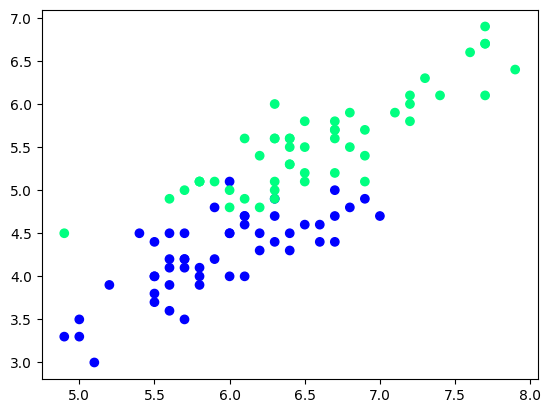

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.scatter(df['SepalLengthCm'],df['PetalLengthCm'],c = df['Species'],cmap = 'winter')
plt.show()

*Taking Only 10 rows for training*

In [11]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(10)
df_test = df.iloc[80:,:].sample(5)

In [12]:
df_train

,SepalLengthCm,PetalLengthCm,Species
72,6.3,4.9,1
56,6.3,4.7,1
74,6.4,4.3,1
143,6.8,5.9,2
69,5.6,3.9,1
144,6.7,5.7,2
121,5.6,4.9,2
125,7.2,6.0,2
91,6.1,4.6,1
81,5.5,3.7,1


In [13]:
df_val

,SepalLengthCm,PetalLengthCm,Species
104,6.5,5.8,2
120,6.9,5.7,2
57,4.9,3.3,1
79,5.7,3.5,1
83,6.0,5.1,1
129,7.2,5.8,2
133,6.3,5.1,2
100,6.3,6.0,2
54,6.5,4.6,1
67,5.8,4.1,1


In [14]:
df_test

,SepalLengthCm,PetalLengthCm,Species
61,5.9,4.2,1
135,7.7,6.1,2
98,5.1,3.0,1
117,7.7,6.7,2
78,6.0,4.5,1


In [15]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

# **Case 1 - Bagging**

*Data for tree 1*

In [16]:
df_bag = df_train.sample(8,replace = True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,SepalLengthCm,PetalLengthCm,Species
91,6.1,4.6,1
69,5.6,3.9,1
81,5.5,3.7,1
74,6.4,4.3,1
144,6.7,5.7,2
56,6.3,4.7,1
144,6.7,5.7,2
72,6.3,4.9,1


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [26]:
dt_bag1 = DecisionTreeClassifier()

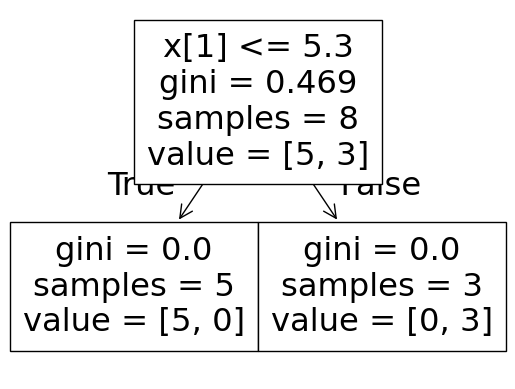

0.9


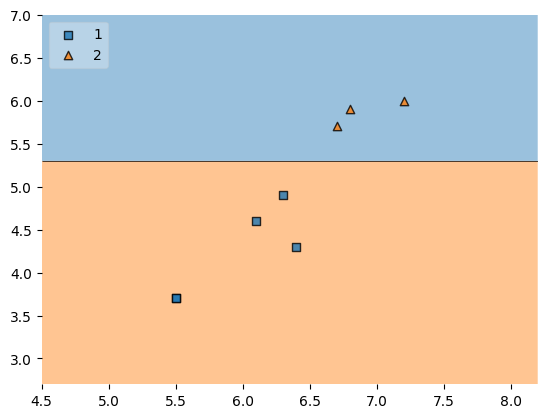

In [34]:
evaluate(dt_bag1,X,y)

In [28]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalLengthCm,PetalLengthCm,Species
91,6.1,4.6,1
125,7.2,6.0,2
56,6.3,4.7,1
69,5.6,3.9,1
144,6.7,5.7,2
69,5.6,3.9,1
74,6.4,4.3,1
121,5.6,4.9,2


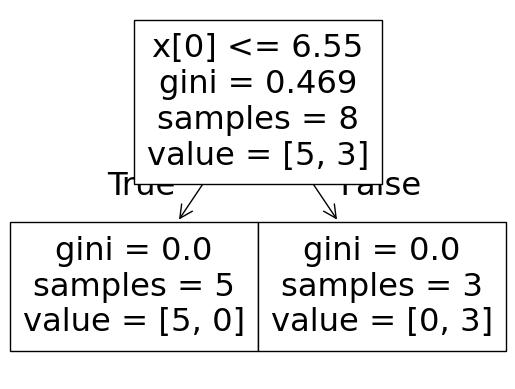

0.7


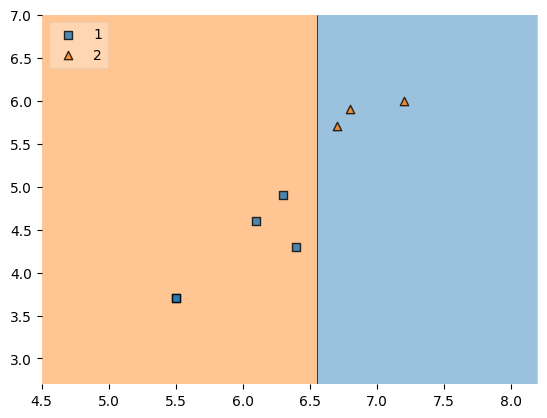

In [33]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [30]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalLengthCm,PetalLengthCm,Species
81,5.5,3.7,1
81,5.5,3.7,1
125,7.2,6.0,2
143,6.8,5.9,2
144,6.7,5.7,2
91,6.1,4.6,1
74,6.4,4.3,1
72,6.3,4.9,1


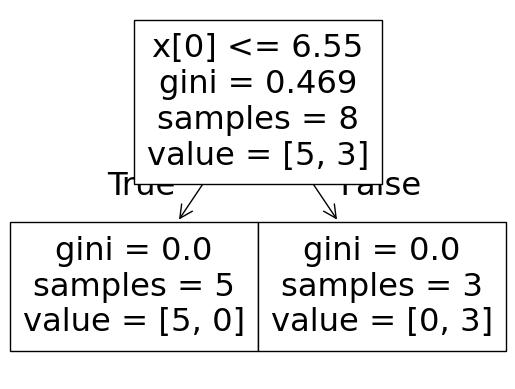

0.7


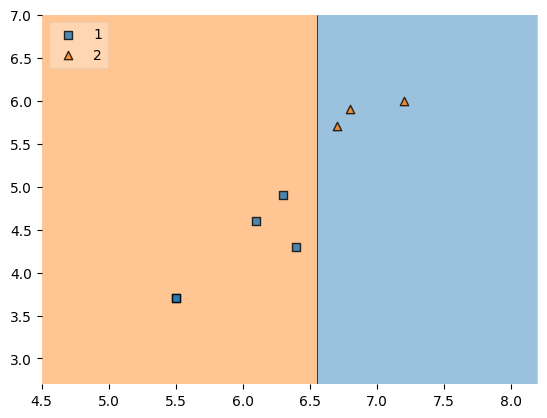

In [32]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [31]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

# **Predict**

In [35]:
df_test

,SepalLengthCm,PetalLengthCm,Species
61,5.9,4.2,1
135,7.7,6.1,2
98,5.1,3.0,1
117,7.7,6.7,2
78,6.0,4.5,1


In [39]:
print("prediction 1",dt_bag1.predict(np.array([7.7,6.7]).reshape(1,2)))
print("prediction 2",dt_bag2.predict(np.array([7.7,6.7]).reshape(1,2)))
print("prediction 3",dt_bag3.predict(np.array([7.7,6.7]).reshape(1,2)))

prediction 1 [2]
prediction 2 [2]
prediction 3 [2]


# **Bagging 3 Types**

# Pasting

In [40]:
# Row Sampling without Replacement
df_train
df_train.sample(8)

,SepalLengthCm,PetalLengthCm,Species
121,5.6,4.9,2
144,6.7,5.7,2
72,6.3,4.9,1
69,5.6,3.9,1
74,6.4,4.3,1
81,5.5,3.7,1
56,6.3,4.7,1
143,6.8,5.9,2


# Random Subspaces

In [41]:
# Column Sampling

df1 = pd.read_csv('/content/Iris.csv')
df1 = df1.sample(10)
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
5,6,5.4,3.9,1.7,0.4,Iris-setosa
43,44,5.0,3.5,1.6,0.6,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
39,40,5.1,3.4,1.5,0.2,Iris-setosa
82,83,5.8,2.7,3.9,1.2,Iris-versicolor
122,123,7.7,2.8,6.7,2.0,Iris-virginica
38,39,4.4,3.0,1.3,0.2,Iris-setosa
105,106,7.6,3.0,6.6,2.1,Iris-virginica
96,97,5.7,2.9,4.2,1.3,Iris-versicolor
57,58,4.9,2.4,3.3,1.0,Iris-versicolor


In [43]:
df1.sample(2,replace=True,axis = 1)

,Species,Species
5,Iris-setosa,Iris-setosa
43,Iris-setosa,Iris-setosa
1,Iris-setosa,Iris-setosa
39,Iris-setosa,Iris-setosa
82,Iris-versicolor,Iris-versicolor
122,Iris-virginica,Iris-virginica
38,Iris-setosa,Iris-setosa
105,Iris-virginica,Iris-virginica
96,Iris-versicolor,Iris-versicolor
57,Iris-versicolor,Iris-versicolor


# Random Patches

In [45]:
df1.sample(8,replace = True).sample(2,replace = True,axis = 1)

,PetalWidthCm,SepalWidthCm
57,1.0,2.4
39,0.2,3.4
122,2.0,2.8
96,1.3,2.9
82,1.2,2.7
57,1.0,2.4
5,0.4,3.9
39,0.2,3.4
